# Concept pool export: nativeness profiles demo (`data.py`)

This notebook demonstrates **`data.py`** from the iteration-2 *concept-pool* dataset artifact. The artifact supports a study of
**how emerging scientific concepts spread across disciplines**, using OpenAlex. It holds 426 concepts, 462,812 works,
488,078 concept–work links, subfield denominators, nativeness profiles, and venue habitats.

`data.py` is the **exporter**. It reads the hydrated raw files (parquet, jsonl, json) and turns every data row into one
example in the `exp_sel_data_out` schema (`{"input", "output", "metadata_*"}`), grouped by dataset. It then splits the result into
parts of less than 90 MB (`full_data_out/full_data_out_k.json`) and writes `mini_*` and `preview_*` variants.

**What this demo runs.** The raw work lists (~1 GB of parquet and abstract text) stay on the run's storage volume. This notebook
therefore runs the exporter on **one** of the seven datasets, **`nativeness_profiles`**. Each raw row gives the exact OpenAlex
count of works tagged with a *legacy concept node*, grouped by `primary_topic.subfield`, for one 5-year block
(2000-04, 2005-09, 2010-14, 2015-19). These profiles tell us which disciplines a node is "native" to. Downstream, they serve as
the reference against which the *host* papers of an emerging concept are compared.

`mini_demo_data.json` holds the raw `p2/profiles.jsonl` rows for 25 of the 1,372 nodes (every 55th node by coverage rank, 4
blocks each, so 100 rows). Everything else is the original code, split into cells.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru, orjson — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3', 'orjson==3.12.0')

# numpy, pandas, matplotlib, pyarrow — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0', 'pyarrow==18.1.0')

## Imports

This is the original import block from `data.py`. The original script also runs `import data as d1`, which loads the
dataset_1 builders from `hyd/data.py`. That module is not shipped with the demo, so the cell below defines a small stand-in
namespace `d1`. It carries the same constants (`LINK_FEATURES`, `WORK_FEATURES`, `TOP_META`) copied verbatim from `hyd/data.py`.

In [2]:
import sys
from pathlib import Path

import orjson
import pyarrow.parquet as pq
from loguru import logger

# --- extra imports for the notebook (data loading + visualisation) ---
import json
from types import SimpleNamespace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Stand-in for `import data as d1` (hyd/data.py). Constants copied verbatim; the d1 builders
# (concept_meta, ds_concept_pool, ds_links, ds_denominators) need the full hyd/ files and are not used here.
_LINK_FEATURES = ["concept_id", "work_id", "year"]
_WORK_FEATURES = ["work_id", "publication_year", "type", "language", "doi_present", "s2_corpus_id", "primary_topic_id",
                  "topic_score", "topics_top3", "source_id", "source_type", "n_refs", "refs_in_corpus", "author_ids",
                  "keyword_idx", "concept_ids", "has_abstract", "abstract_n_tokens", "cited_by_count", "dup_group"]
d1 = SimpleNamespace(
    LINK_FEATURES=_LINK_FEATURES,
    WORK_FEATURES=_WORK_FEATURES,
    TOP_META={
        "description": "Concept pool 2005-2016 artifact (see README.md). One example per data row, grouped by dataset.",
        "feature_names": {"concept_work_links": _LINK_FEATURES, "openalex_works": _WORK_FEATURES},
        "notes": {"openalex_works": "input is a JSON array in feature_names order; output = primary_topic subfield_id; full "
                                    "refs/institutions/scores in works/works_part_XX.parquet",
                  "concept_work_links": "input = [concept_id, work_id, year]; output = match_evidence; concept details in "
                                        "concept_pool_2005_2016"}},
)

## Load the demo data

The notebook first tries the GitHub raw URL, which works in Colab after the repository is published. If that fails, it falls back
to a local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-2/dataset-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print("raw profile rows:", len(data["profiles"]), "| nodes:", len({r["node_id"] for r in data["profiles"]}))

Demo subset of the iteration-2 concept-pool artifact: raw source rows of the nativeness_profiles dataset (p2/profiles.jsonl), i.e. exact OpenAlex primary_topic.subfield x 5-year-block work counts for legacy-concept nodes that co-occur with the pool's emerging concepts in host (non-origin) papers.
raw profile rows: 100 | nodes: 25


## Config

These are all the tunable parameters.
* `N_NODES` is the number of legacy-concept nodes (each with 4 block rows) passed to the exporter. The demo file has 25; the full
  artifact has 1,372.
* `PART_LIMIT` is the byte budget per `full_data_out_k.json` part. The original is **85,000,000** (< 90 MB per file). The demo
  uses a tiny limit so that the part-splitting logic actually runs on 100 rows.
* `MINI_N` is the number of examples per dataset in the `mini_*` files (original: 3).
* `PREVIEW_CHARS` is the string truncation length in the `preview_*` files (original: 200).

In [5]:
N_NODES = 25              # nodes to export (demo file holds 25; full artifact: 1,372 nodes = 5,488 rows)
PART_LIMIT_DEMO = 100_000 # bytes per full_data_out part; ORIGINAL: 85_000_000
MINI_N = 3                # examples per dataset in mini_* files; ORIGINAL: 3
PREVIEW_CHARS = 200       # string truncation in preview_* files; ORIGINAL: 200
OUT_DIR = Path("demo_out")  # stands in for the artifact ROOT (where data.py writes its outputs)

## Setup: paths, part limit, JSON helper and logging

In the original, `ROOT` is the script's directory and `HYD = ROOT / "hyd"` holds the hydrated raw data. Here `ROOT` points to
`OUT_DIR`, so all outputs land in `demo_out/`. `J` serialises a Python object to a compact JSON string with orjson. Each
example's `input` and `output` are stored as such strings.

In [6]:
ROOT = OUT_DIR  # original: Path(__file__).resolve().parent
ROOT.mkdir(exist_ok=True)
HYD = ROOT / "hyd"  # not present in the demo (raw parquet/abstract store stays on the run volume)

PART_LIMIT = PART_LIMIT_DEMO  # original: 85_000_000
J = lambda o: orjson.dumps(o).decode()  # noqa: E731

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(ROOT / "logs" / "data.log", rotation="30 MB", level="DEBUG")

2

## Row builders: one function per dataset

Each `ds_*` function turns one raw source into a list of examples.

* **`ds_profiles`** (run in this demo) reads the per-(node, block) profile rows and sorts them by `(coverage_rank, block)`. For
  each row it emits the following fields:
  * `input`: the node id, type, name, OpenAlex concept level and block.
  * `output`: the exact total work count, `{subfield_id: count}` (the top 200 groups; `unknown` counts works without a primary
    topic), the number of groups, and whether the profile was truncated at 200 groups.
  * `metadata_*`: the node's rank by host (non-origin) co-occurrence weight with the pool's emerging concepts, and its
    cumulative weight share. The first 1,372 nodes cover 78.7% of host weight.
  * provenance: the retrieval time, the API credits used and the exact OpenAlex filter.

  The only change from the original is the source of the rows. The original parses `p2/profiles.jsonl` from disk; the demo
  receives the same rows from the loaded `data`.
* `ds_works`, `ds_coverage` and `ds_venues` are kept **verbatim for reference**. They read `hyd/works/*.parquet`,
  `outputs/nativeness_coverage.json` and `outputs/venue_habitat_asjc.json`, which are not part of the demo data, so they are
  defined here but not called.

In [7]:
def ds_works() -> list[dict]:
    out = []
    cols = d1.WORK_FEATURES + ["subfield_id", "field_id", "domain_id", "retrieval_batch"]
    for p in sorted((HYD / "works").glob("works_part_*.parquet")):
        for r in pq.read_table(p, columns=cols).to_pylist():
            if r["topic_score"] is not None:
                r["topic_score"] = round(float(r["topic_score"]), 4)
            sf = r["subfield_id"]
            out.append({"input": J([r[k] for k in d1.WORK_FEATURES]),
                        "output": str(sf) if sf is not None else "unknown",
                        "metadata_field_id": r["field_id"], "metadata_domain_id": r["domain_id"],
                        "metadata_retrieval_batch": r["retrieval_batch"]})
    return out


def ds_profiles() -> list[dict]:
    out = []
    # original: p = ROOT / "p2" / "profiles.jsonl"
    #           rows = [orjson.loads(x) for x in p.read_text().splitlines() if x.strip()] if p.exists() else []
    rows = [dict(r) for r in profile_rows]  # demo: same raw rows, taken from mini_demo_data.json
    rows.sort(key=lambda r: (r["coverage_rank"], r["block"]))
    for r in rows:
        inp = {"node_id": r["node_id"], "node_type": r["node_type"], "display_name": r["display_name"],
               "level": r["level"], "block": r["block"]}
        outp = {"total": r["total"], "subfield_counts": r["subfield_counts"], "n_groups": r["n_groups"],
                "truncated_top200": r["truncated_top200"]}
        out.append({"input": J(inp), "output": J(outp), "metadata_coverage_rank": r["coverage_rank"],
                    "metadata_host_cooc_weight": r["host_cooc_weight"],
                    "metadata_cum_weight_share": round(r["cum_weight_share"], 6), "metadata_frame": r["frame"],
                    "metadata_retrieved_utc": r["retrieved_utc"], "metadata_credits": r["credits"],
                    "metadata_request_filter": r["request_filter"]})
    return out


def ds_coverage() -> list[dict]:
    d = orjson.loads((ROOT / "outputs" / "nativeness_coverage.json").read_bytes())
    out = []
    for r in d["concepts"]:
        out.append({"input": J({"concept_id": r["concept_id"], "origin_subfield": r["origin_subfield"]}),
                    "output": J({"covered_weight_share": r["covered_weight_share"],
                                 "n_host_cpapers": r["n_host_cpapers"], "n_distinct_nodes": r["n_distinct_nodes"],
                                 "host_weight": r["host_weight"]}),
                    "metadata_phrase": r["phrase"], "metadata_arm": r["arm"], "metadata_origin_rule": r["origin_rule"]})
    o = d["overall"]
    out.append({"input": J({"concept_id": "__OVERALL__", "origin_subfield": None}), "output": J(o),
                "metadata_phrase": None, "metadata_arm": "overall", "metadata_origin_rule": None})
    return out


def ds_venues() -> list[dict]:
    d = orjson.loads((ROOT / "outputs" / "venue_habitat_asjc.json").read_bytes())
    out = []
    for v in d["venues"]:
        inp = {"source_id": v["source_id"], "issn_l": v.get("issn_l"), "issns": v.get("issns"),
               "display_name": v.get("display_name"), "openalex_type": v.get("openalex_type")}
        outp = {"habitat_subfield": v["habitat_subfield"], "fractional_shares": v["fractional_shares"],
                "asjc_codes_raw": v["asjc_codes_raw"]}
        out.append({"input": J(inp), "output": J(outp), "metadata_route": v["route"],
                    "metadata_sjr_year_used": v["sjr_year_used"], "metadata_uncovered_reason": v["uncovered_reason"],
                    "metadata_n_c_papers": v["n_c_papers"], "metadata_citation_independent": v["citation_independent"],
                    "metadata_habitat_in_openalex_subfields": v.get("habitat_in_openalex_subfields"),
                    "metadata_asjc_codes_union_2005_2010_2015_2019": J(v.get("asjc_codes_union_2005_2010_2015_2019")),
                    "metadata_scopus_source_ids": J(v.get("scopus_source_ids")),
                    "metadata_general_field": v.get("general_field"),
                    "metadata_preperiod_dominant_share": v.get("preperiod_dominant_share")})
    return out

Select the first `N_NODES` nodes, by coverage rank, from the demo rows. Each node keeps all 4 blocks.

In [8]:
_ranks = sorted({r["coverage_rank"] for r in data["profiles"]})[:N_NODES]
profile_rows = [r for r in data["profiles"] if r["coverage_rank"] in set(_ranks)]
print(f"{len(profile_rows)} raw rows for {len(_ranks)} nodes (coverage ranks {_ranks[0]}..{_ranks[-1]})")

100 raw rows for 25 nodes (coverage ranks 1..1321)


## Top-level metadata

`TOP_META` goes at the top of every output file. It records the column order of the array-encoded `input`s
(`feature_names`) and a note per dataset explaining how to read it. This cell is unchanged from the original.

In [9]:
TOP_META = {
    "description": "Iteration-2 concept-pool artifact (see README.md). One example per data row, grouped by dataset.",
    "feature_names": {"concept_work_links": d1.LINK_FEATURES, "openalex_works": d1.WORK_FEATURES},
    "notes": {**d1.TOP_META["notes"],
              "subfield_year_totals": "dataset_1 D4 copied unchanged; the 'all_types' variant is the per-10^4 "
                                      "denominator (c-papers include every work type)",
              "nativeness_profiles": "exact OpenAlex meta.count and group_by counts, never sample-based; frame = all "
                                     "types; 'unknown' = works without a primary topic",
              "venue_habitat_asjc": "habitat_subfield = 4-digit ASJC code (= OpenAlex subfield id where one exists) "
                                    "or 'UNCOVERED'; route preperiod_groupby is NOT citation-independent"}}

## Writers: size-limited parts, plus mini and preview variants

* `trunc` recursively truncates every string. The preview files use it so that they are safe to open.
* `write_small` writes `mini_<stem>.json` (the first few examples of each dataset) and `preview_<stem>.json` (mini with strings
  truncated).
* `write_parts` streams all examples into parts of at most `PART_LIMIT` bytes. A dataset can span two parts, so each part lists
  `{"dataset", "examples"}` chunks. It then writes `full_data_out_k.json` and a mini/preview pair for each part.

The demo uses the config values `MINI_N` and `PREVIEW_CHARS`; the original hard-coded 3 and 200.

In [10]:
def trunc(o, n: int = PREVIEW_CHARS):
    """Preview variant: every string truncated to n characters (recursively)."""
    if isinstance(o, str):
        return o if len(o) <= n else o[:n] + "..."
    if isinstance(o, list):
        return [trunc(x, n) for x in o]
    if isinstance(o, dict):
        return {k: trunc(v, n) for k, v in o.items()}
    return o


def write_small(path_stem: Path, datasets: list[dict]) -> None:
    """mini_* (3 examples per dataset) and preview_* (mini with strings truncated to 200 chars)."""
    mini = {"metadata": TOP_META, "datasets": [{"dataset": d["dataset"], "examples": d["examples"][:MINI_N]}
                                               for d in datasets]}
    (path_stem.parent / f"mini_{path_stem.name}.json").write_bytes(orjson.dumps(mini, option=orjson.OPT_INDENT_2))
    (path_stem.parent / f"preview_{path_stem.name}.json").write_bytes(
        orjson.dumps(trunc(mini), option=orjson.OPT_INDENT_2))


def write_parts(datasets: list[dict]) -> None:
    out_dir = ROOT / "full_data_out"
    out_dir.mkdir(exist_ok=True)
    for old in sorted(out_dir.glob("*.json")):
        old.unlink()
    parts, cur, size = [], [], 0
    for d in datasets:
        chunk = []
        for e in d["examples"]:
            b = len(orjson.dumps(e)) + 1
            if size + b > PART_LIMIT and (chunk or cur):
                if chunk:
                    cur.append({"dataset": d["dataset"], "examples": chunk})
                parts.append(cur)
                cur, chunk, size = [], [], 0
            chunk.append(e)
            size += b
        if chunk:
            cur.append({"dataset": d["dataset"], "examples": chunk})
    if cur:
        parts.append(cur)
    for k, p in enumerate(parts, 1):
        (out_dir / f"full_data_out_{k}.json").write_bytes(orjson.dumps({"metadata": TOP_META, "datasets": p}))
        write_small(out_dir / f"data_out_{k}", p)
        logger.info(f"part {k}: " + ", ".join(f"{x['dataset']}={len(x['examples'])}" for x in p))
    logger.info(f"wrote {len(parts)} parts to full_data_out/")

## Main: build every dataset, then write the parts and the root mini/preview files

In the original, `builders` maps all seven dataset names to their builder functions. The builders the demo data cannot feed are
commented out. Otherwise the loop is identical: build, log the count, skip empty datasets, write the parts, and write the root
`mini_data_out.json` / `preview_data_out.json`.

In [11]:
@logger.catch(reraise=True)
def main() -> None:
    # cm = d1.concept_meta()   # needs hyd/ (full artifact only)
    builders = {
        # "concept_pool_2005_2016": d1.ds_concept_pool,   # full artifact only
        # "concept_work_links": lambda: d1.ds_links(cm),  # full artifact only
        # "openalex_works": ds_works,                     # full artifact only (hyd/works/*.parquet)
        # "subfield_year_totals": d1.ds_denominators,     # full artifact only
        "nativeness_profiles": ds_profiles,
        # "nativeness_coverage": ds_coverage,             # full artifact only (outputs/nativeness_coverage.json)
        # "venue_habitat_asjc": ds_venues,                # full artifact only (outputs/venue_habitat_asjc.json)
    }
    datasets = []
    for n, fn in builders.items():
        ex = fn()
        logger.info(f"{n}: {len(ex)} examples")
        if not ex:
            logger.warning(f"{n}: no rows yet, dataset left out of this export")
            continue
        datasets.append({"dataset": n, "examples": ex})
    write_parts(datasets)
    write_small(ROOT / "data_out", datasets)  # root mini_data_out.json / preview_data_out.json: 3 per dataset


main()

12:13:21|INFO   |nativeness_profiles: 100 examples


12:13:21|INFO   |part 1: nativeness_profiles=49


12:13:21|INFO   |part 2: nativeness_profiles=48


12:13:21|INFO   |part 3: nativeness_profiles=3


12:13:21|INFO   |wrote 3 parts to full_data_out/


## Results: inspect the exported files and what the profiles show

The cell below reads the written parts back and decodes the JSON-string `input`/`output` fields. It then summarises each node:
* **total works** per block, which shows the growth of the node;
* **top subfield share**: how concentrated the node is in its single most common subfield;
* **normalised Shannon entropy** over subfields (0 = one subfield, 1 = uniform). Higher entropy means the node is spread
  across more disciplines.

These are the quantities the downstream analysis uses to judge whether an emerging concept's host neighbourhood is "native"
to a discipline.

In [12]:
files = sorted((ROOT / "full_data_out").glob("*.json"))
print("written files:")
for f in files + sorted(ROOT.glob("*_data_out.json")):
    print(f"  {f}  {f.stat().st_size:>9,d} B")

ex = []
for f in sorted((ROOT / "full_data_out").glob("full_data_out_*.json"), key=lambda p: int(p.stem.split("_")[-1])):
    for d in orjson.loads(f.read_bytes())["datasets"]:
        for e in d["examples"]:
            ex.append({**json.loads(e["input"]), **json.loads(e["output"]),
                       "rank": e["metadata_coverage_rank"], "cum_share": e["metadata_cum_weight_share"],
                       "host_w": e["metadata_host_cooc_weight"], "part": f.stem})
print(f"\nre-read {len(ex)} examples from {len({e['part'] for e in ex})} full_data_out part(s)")

def _stats(c):
    v = np.array([x for k, x in c.items() if k != "unknown"], dtype=float)
    p = v / v.sum()
    H = -(p * np.log(p)).sum() / np.log(len(p)) if len(p) > 1 else 0.0
    top = max(((k, x) for k, x in c.items() if k != "unknown"), key=lambda t: t[1])
    return top[0], top[1] / v.sum(), H, c.get("unknown", 0) / sum(c.values())

rows = []
for e in ex:
    top_sf, top_share, H, unk = _stats(e["subfield_counts"])
    rows.append({"rank": e["rank"], "node": e["display_name"], "level": e["level"], "block": e["block"],
                 "total": e["total"], "n_groups": e["n_groups"], "trunc200": e["truncated_top200"],
                 "top_subfield": top_sf, "top_share": round(top_share, 3), "entropy": round(H, 3),
                 "unknown_share": round(unk, 3), "part": e["part"]})
df = pd.DataFrame(rows)
pd.set_option("display.width", 200); pd.set_option("display.max_rows", 200)
summary = df.pivot_table(index=["rank", "node", "level"], columns="block", values="entropy").round(3)
summary["top_subfield_2015_19"] = df[df.block == "2015-2019"].set_index(["rank", "node", "level"])["top_subfield"]
summary["works_2015_19"] = df[df.block == "2015-2019"].set_index(["rank", "node", "level"])["total"]
print("\nNormalised subfield entropy per block (0 = single-discipline, 1 = uniform):")
print(summary.to_string())

written files:
  demo_out/full_data_out/full_data_out_1.json    100,506 B
  demo_out/full_data_out/full_data_out_2.json    100,200 B
  demo_out/full_data_out/full_data_out_3.json      8,625 B
  demo_out/full_data_out/mini_data_out_1.json     12,544 B
  demo_out/full_data_out/mini_data_out_2.json      8,989 B
  demo_out/full_data_out/mini_data_out_3.json      9,356 B
  demo_out/full_data_out/preview_data_out_1.json      4,090 B
  demo_out/full_data_out/preview_data_out_2.json      4,095 B
  demo_out/full_data_out/preview_data_out_3.json      4,146 B
  demo_out/mini_data_out.json     12,544 B
  demo_out/preview_data_out.json      4,090 B



re-read 100 examples from 3 full_data_out part(s)

Normalised subfield entropy per block (0 = single-discipline, 1 = uniform):
block                                        2000-2004  2005-2009  2010-2014  2015-2019 top_subfield_2015_19  works_2015_19
rank node                             level                                                                                
1    Computer science                 0          0.752      0.763      0.780      0.810                 2202       17634065
56   Natural language processing      1          0.555      0.543      0.553      0.553                 1702         241450
111  Electron                         2          0.517      0.515      0.521      0.528                 3107         145688
166  Covariance                       2          0.731      0.713      0.699      0.701                 1702          15949
221  Big data                         2          0.801      0.747      0.650      0.666                 1710          66116
276 

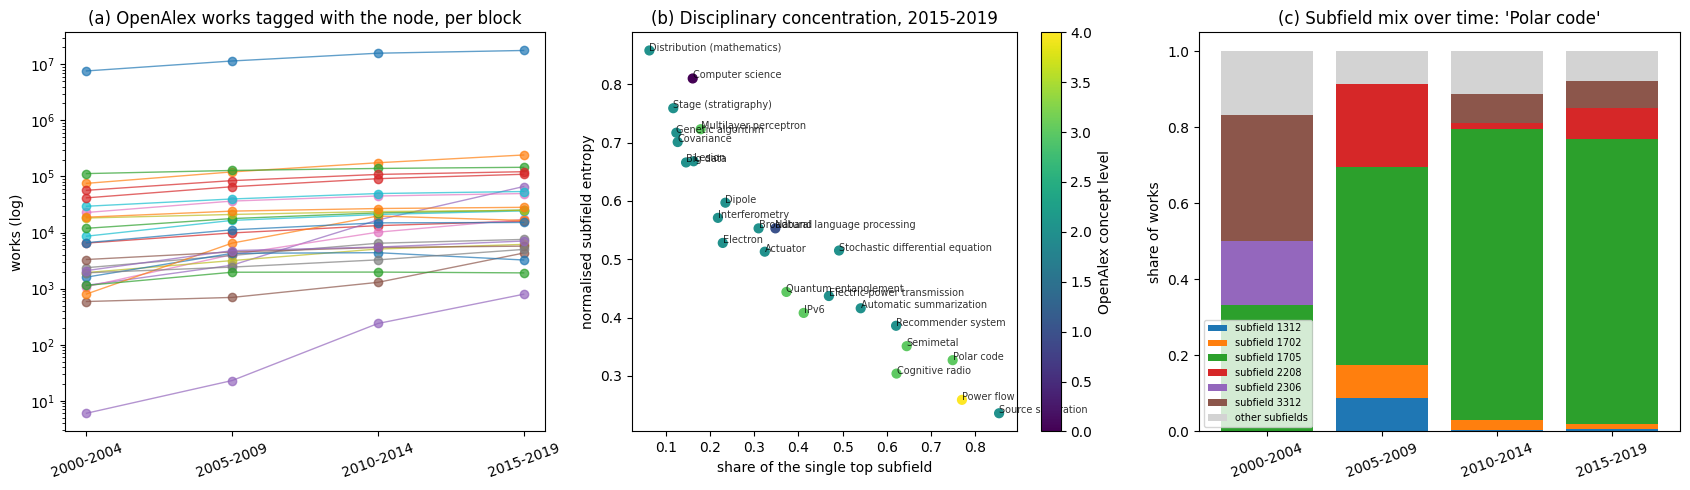

Example exported row (first example, as stored in full_data_out_1.json, strings truncated):
{
 "input": "{\"node_id\":\"C41008148\",\"node_type\":\"legacy_concept\",\"display_name\":\"Computer science\",\"level\":0,\"block\":\"2000-2004\"}",
 "output": "{\"total\":7609260,\"subfield_counts\":{\"2202\":1843318,\"unknown\":378027,\"2208\":298104,\"1702\":246095,\"1705\":198069,\"3312\":191693,\"2207\":180078,\"2002\":175705,\"1710\":1...",
 "metadata_coverage_rank": 1,
 "metadata_host_cooc_weight": 59526,
 "metadata_cum_weight_share": 0.054276,
 "metadata_frame": "all_types (no type filter)",
 "metadata_retrieved_utc": "2026-09-29T00:03:29Z",
 "metadata_credits": 1,
 "metadata_request_filter": "concepts.id:C41008148,publication_year:2000-2004"
}


In [13]:
blocks = ["2000-2004", "2005-2009", "2010-2014", "2015-2019"]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) growth: total works per block (log scale), one line per node
for (rank, node), g in df.groupby(["rank", "node"]):
    g = g.set_index("block").loc[blocks]
    axes[0].plot(blocks, g["total"], marker="o", lw=1, alpha=.7, label=f"{node} (#{rank})")
axes[0].set_yscale("log"); axes[0].set_title("(a) OpenAlex works tagged with the node, per block")
axes[0].set_ylabel("works (log)"); axes[0].tick_params(axis="x", rotation=20)

# (b) concentration vs. spread in the latest block
last = df[df.block == "2015-2019"]
sc = axes[1].scatter(last["top_share"], last["entropy"], c=last["level"], cmap="viridis", s=40)
for _, r in last.iterrows():
    axes[1].annotate(r["node"], (r["top_share"], r["entropy"]), fontsize=7, alpha=.8)
axes[1].set_xlabel("share of the single top subfield"); axes[1].set_ylabel("normalised subfield entropy")
axes[1].set_title("(b) Disciplinary concentration, 2015-2019"); plt.colorbar(sc, ax=axes[1], label="OpenAlex concept level")

# (c) subfield composition over time for the node with the largest entropy change
chg = (df.pivot_table(index="node", columns="block", values="entropy")[blocks[-1]]
       - df.pivot_table(index="node", columns="block", values="entropy")[blocks[0]]).abs().idxmax()
sel = {e["block"]: e["subfield_counts"] for e in ex if e["display_name"] == chg}
tot = {b: sum(v for k, v in sel[b].items() if k != "unknown") for b in blocks}
top_sfs = sorted({k for b in blocks for k, _ in sorted(((k, v) for k, v in sel[b].items() if k != "unknown"),
                                                        key=lambda t: -t[1])[:3]})
bottom = np.zeros(len(blocks))
for sf in top_sfs:
    vals = np.array([sel[b].get(sf, 0) / tot[b] for b in blocks])
    axes[2].bar(blocks, vals, bottom=bottom, label=f"subfield {sf}"); bottom += vals
axes[2].bar(blocks, 1 - bottom, bottom=bottom, color="lightgrey", label="other subfields")
axes[2].set_title(f"(c) Subfield mix over time: '{chg}'"); axes[2].set_ylabel("share of works")
axes[2].legend(fontsize=7); axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

print("Example exported row (first example, as stored in full_data_out_1.json, strings truncated):")
print(json.dumps(trunc(orjson.loads((ROOT / 'full_data_out' / 'full_data_out_1.json').read_bytes())['datasets'][0]['examples'][0], 160), indent=1))